In [77]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

sns.set()

In [78]:
base_dir = '/home/shiva/Datasets/Euroc_Datasets'
working_dir = 'V2_01_easy_Added_Noise/mav0/imu0'

df_imu = pd.read_csv(f'{base_dir}/{working_dir}/data_orig.csv')

In [79]:
df_imu.rename(columns={"#timestamp [ns]": "timestamp_[ns]"}, inplace=True)

In [80]:
cols = df_imu.columns

In [81]:
df_imu.head(5)

,timestamp_[ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2]
0,1413393212225760512,0.094946,0.020246,0.058643,9.128357,0.106239,-2.606934
1,1413393212230760448,0.058643,0.035605,0.051662,9.422556,1.160454,-2.623279
2,1413393212235760384,-0.011170,0.027925,0.069813,9.398040,1.618097,-2.705001
3,1413393212240760576,-0.072606,0.033510,0.069813,9.496106,0.670121,-2.819412
4,1413393212245760512,-0.092153,0.036303,0.078889,8.989429,-0.130755,-2.713173


In [82]:
df_imu.describe()

,timestamp_[ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2]
count,2.280000e+04,22800.000000,22800.000000,22800.000000,22800.000000,22800.000000,22800.000000
mean,1.413393e+18,-0.013423,0.025550,0.084942,9.264657,0.026425,-3.099465
std,3.290969e+10,0.252203,0.133229,0.160564,1.368679,0.747690,0.731681
min,1.413393e+18,-0.770039,-0.950855,-0.723963,0.514849,-3.309744,-15.886773
25%,1.413393e+18,-0.104022,-0.043284,-0.004189,8.401030,-0.416783,-3.546738
50%,1.413393e+18,-0.008378,0.025133,0.083776,9.283629,0.032689,-3.048234
75%,1.413393e+18,0.069115,0.096342,0.184307,10.051816,0.473988,-2.647795
max,1.413393e+18,1.186824,1.408830,1.170069,31.242352,5.410002,0.514849


In [83]:
values_to_generate = df_imu.shape[0]

In [84]:
df_imu_cpy = df_imu.copy(deep=True)

In [102]:
np.sqrt(3.1**2 - 0.66**2)

np.float64(3.0289272028228083)

In [92]:
# Gyroscope data modification.

# noise_std_dev = np.sqrt(3.1**2 - 0.66**2)
noise_std_dev = 0.01

for col in cols[1:4]:
    print(f"Adding noise to: {col}.")
    noise_distribution = np.random.normal(0, noise_std_dev, size=values_to_generate)
    df_imu_cpy[col] = df_imu[col] + noise_distribution

Adding noise to: w_RS_S_x [rad s^-1].
Adding noise to: w_RS_S_y [rad s^-1].
Adding noise to: w_RS_S_z [rad s^-1].


In [93]:
# Accelerometer data modification.

# noise_std_dev = np.sqrt(0.3**2 - 0.11**2)
noise_std_dev = 0.01

for col in cols[4:7]:
    print(f"Adding noise to: {col}.")
    noise_distribution = np.random.normal(0, noise_std_dev, size=values_to_generate)
    df_imu_cpy[col] = df_imu[col] + noise_distribution

Adding noise to: a_RS_S_x [m s^-2].
Adding noise to: a_RS_S_y [m s^-2].
Adding noise to: a_RS_S_z [m s^-2].


In [94]:
# Using pandas describe does not give a good impression of the change since that is summarised across the entire dataset.
# Below we investigate a few records.

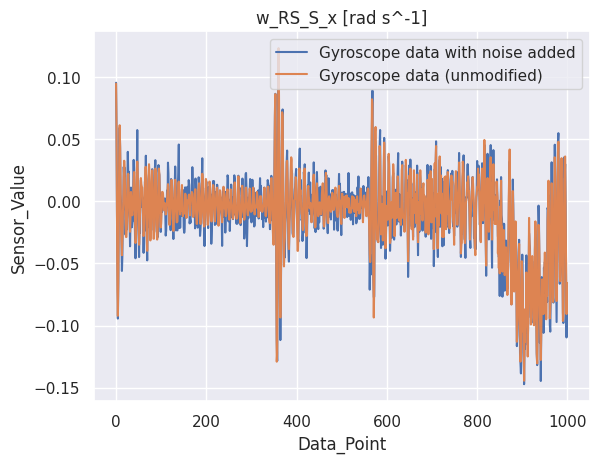

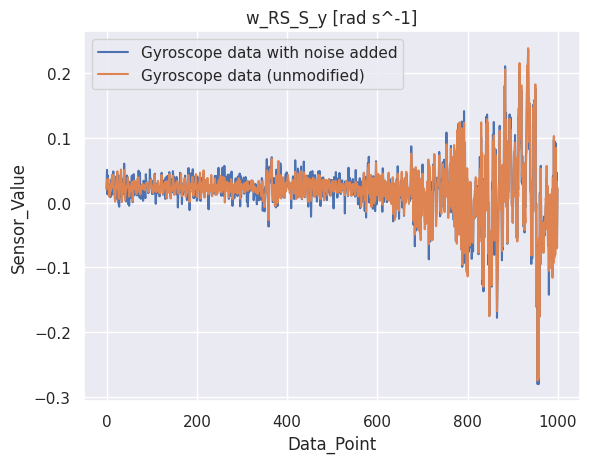

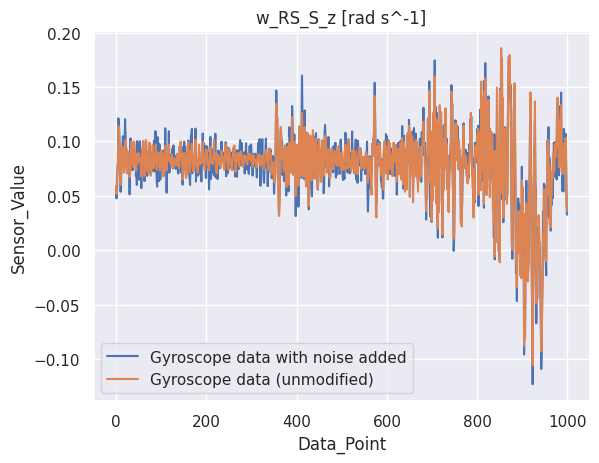

In [95]:
# Gyroscope analysis

num_data_points_to_consider = 1000

for col in cols[1:4]:
    x = range(num_data_points_to_consider)
    y1 = df_imu_cpy[0:num_data_points_to_consider][col]
    y2 = df_imu[0:num_data_points_to_consider][col]
    
    # Plotting multiple lines
    plt.plot(x, y1, label='Gyroscope data with noise added')
    plt.plot(x, y2, label='Gyroscope data (unmodified)')
    plt.legend()
    plt.title(f'{col}')
    plt.xlabel('Data_Point')
    plt.ylabel('Sensor_Value')
    plt.show()

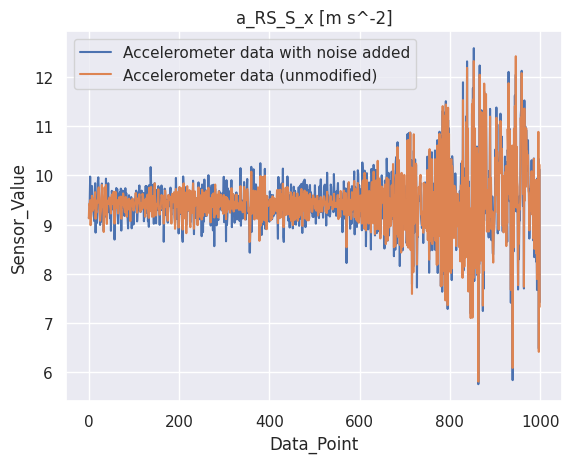

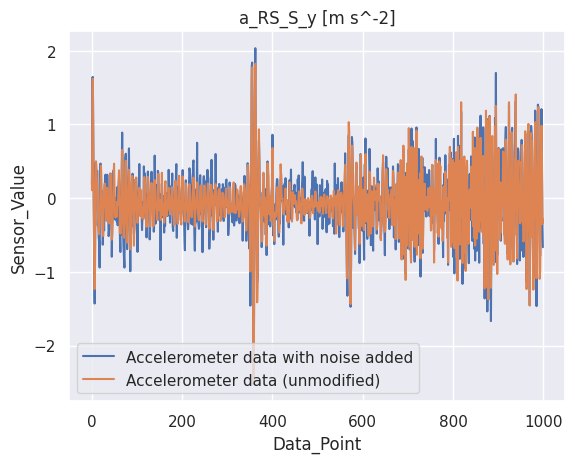

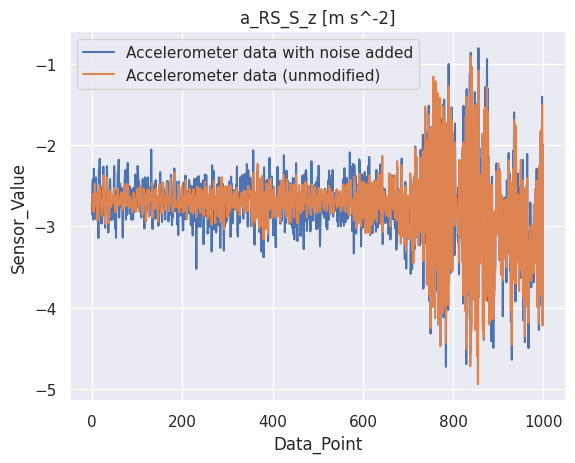

In [97]:
# Accelerometer analysis

num_data_points_to_consider = 1000

for col in cols[4:7]:
    x = range(num_data_points_to_consider)
    y1 = df_imu_cpy[0:num_data_points_to_consider][col]
    y2 = df_imu[0:num_data_points_to_consider][col]
    
    # Plotting multiple lines
    plt.plot(x, y1, label='Accelerometer data with noise added')
    plt.plot(x, y2, label='Accelerometer data (unmodified)')
    plt.legend()
    plt.title(f'{col}')
    plt.xlabel('Data_Point')
    plt.ylabel('Sensor_Value')
    plt.show()

In [98]:
df_imu_cpy.rename(columns={"timestamp_[ns]":"#timestamp [ns]"}, inplace=True)

In [100]:
df_imu_cpy.head(5)

,#timestamp [ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2]
0,1413393212225760512,0.095692,0.022206,0.058702,9.138262,0.186686,-2.852418
1,1413393212230760448,0.057284,0.050364,0.047610,9.167611,1.637927,-2.460404
2,1413393212235760384,-0.007580,0.012642,0.052318,9.494773,1.642562,-2.422103
3,1413393212240760576,-0.055394,0.041656,0.074902,9.976332,0.688028,-2.917082
4,1413393212245760512,-0.094422,0.024756,0.080808,9.168581,-0.117445,-2.290377


In [101]:
df_imu_cpy.to_csv(f'{base_dir}/{working_dir}/data.csv', index=False)